# Engagement vs “vanity” (Hiraya Haven)

**Pipeline:** Distinguish posts that generate engagement from posts that generate donation-driving outcomes.

**Data:** `social_media_posts` from `../Data/hiraya.db`.

**Predictive:** classify high `donation_referrals` vs low.

**Explanatory:** compare engagement-heavy vs donation-heavy segments by post attributes (platform, CTA, topic, boosted).

> **IS455 pipeline structure:** (1) Problem framing → (2) Data acquisition, preparation & exploration → (3) Modeling → (4) Evaluation & selection → (5) Feature selection & interpretation → (6) Explanatory analysis (associations; not causal proof) → (7) Deployment.

## 1. Problem framing

Hiraya Haven needs to learn which content drives meaningful action (donations) vs likes/comments (“vanity metrics”) (`IntexContext.txt`).

- **Predictive goal:** classify posts likely to fall in the “high donation referrals” segment.
- **Explanatory goal:** compare the attributes of engagement-heavy vs donation-heavy posts.

**Success metrics:** ROC-AUC / AP; and clear, actionable segment differences.

## 2. Data acquisition, preparation & exploration

Data comes from `social_media_posts` in `../Data/hiraya.db`. We compute a simple engagement score and define “high” thresholds via percentiles.

## 3. Modeling

Logistic regression with categorical encodings + scaled numeric fields.

## 4. Evaluation & selection

Report ROC-AUC / AP. In business terms: how well can we find the top segment of posts likely to drive donations?

## 5. Feature selection & interpretation

Inspect **logistic coefficients** on one-hot features (after preprocessing) for directionality; pair with segment EDA plots (cell 3) for narrative.

## 6. Explanatory analysis (associations; not causal proof)

This is observational and platform-specific; boosting and campaign timing confound associations. Treat insights as hypotheses.

## 7. Deployment

Use as a content strategy dashboard and monitoring tool (segment mix over time, by platform and topic).

In [1]:
# ============================================================================
# Engagement vs vanity — Define engagement and donation outcomes per post
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Builds engagement_score from likes+comments+shares; donation_referrals from platform fields.
# 75th-percentile "high" labels are calibrated on the training split only (Ch. 15 — no full-sample thresholds).
# np.select labels posts as both_high, engagement_only, donation_only, or neither for EDA.
#
from __future__ import annotations

import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path("..").resolve()
DB_PATH = ROOT / "Data" / "hiraya.db"

with sqlite3.connect(DB_PATH) as conn:
    posts = pd.read_sql_query('SELECT * FROM "social_media_posts"', conn)

# Define two outcomes:
# - engagement_score: likes+comments+shares
# - donation_referrals (already in table)
posts["engagement_score"] = posts[["likes", "comments", "shares"]].fillna(0).sum(axis=1)
posts["donation_referrals"] = posts["donation_referrals"].fillna(0).astype(int)

# Train/test index for threshold calibration (same indices as predictive cell below).
_idx = np.arange(len(posts))
train_idx, test_idx = train_test_split(_idx, test_size=0.25, random_state=42)
eng_thresh = posts.iloc[train_idx]["engagement_score"].quantile(0.75)
don_thresh = posts.iloc[train_idx]["donation_referrals"].quantile(0.75)

posts["high_engagement"] = (posts["engagement_score"] >= eng_thresh).astype(int)
posts["high_donation"] = (posts["donation_referrals"] >= don_thresh).astype(int)

# Segment labels for EDA
posts["segment"] = np.select(
    [
        (posts["high_engagement"] == 1) & (posts["high_donation"] == 1),
        (posts["high_engagement"] == 1) & (posts["high_donation"] == 0),
        (posts["high_engagement"] == 0) & (posts["high_donation"] == 1),
    ],
    ["both_high", "engagement_only", "donation_only"],
    default="neither",
)

posts["segment"].value_counts()

segment
neither            505
both_high          126
donation_only       92
engagement_only     89
Name: count, dtype: int64

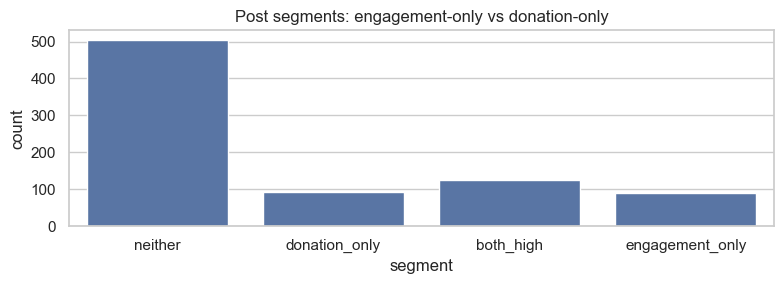

In [2]:
# ============================================================================
# Segment summary tables and bar chart
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Counts posts by segment × platform × post_type to see where 'vanity' vs 'impact' posts cluster.
#
# Explanatory comparison

seg_summary = posts.groupby(["segment", "platform", "post_type"], as_index=False).agg(n=("post_id", "count"))
seg_summary.sort_values("n", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 3))
sns.countplot(data=posts, x="segment", ax=ax)
ax.set_title("Post segments: engagement-only vs donation-only")
plt.tight_layout()
plt.show()

In [3]:
# ============================================================================
# Predictive model — high_donation from post attributes (in-sample split)
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Logistic regression with one-hot + scaling; stratified split keeps class balance.
# ROC-AUC / average precision summarize ranking quality for referral probability.
# Later cell repeats evaluation with out-of-time split — prefer that for deployment thinking.
#
# Predictive: classify high_donation using post attributes

cat_cols = [
    "platform",
    "day_of_week",
    "post_type",
    "media_type",
    "content_topic",
    "sentiment_tone",
    "has_call_to_action",
    "call_to_action_type",
    "is_boosted",
]

num_cols = [
    "post_hour",
    "num_hashtags",
    "caption_length",
    "reach",
    "impressions",
]

X = posts[cat_cols + num_cols].copy()
y = posts["high_donation"].astype(int)

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

pre = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", Pipeline([("scaler", StandardScaler())]), num_cols),
    ]
)

pipe = Pipeline(
    [
        ("pre", pre),
        ("lr", LogisticRegression(max_iter=500, class_weight="balanced", solver="liblinear")),
    ]
)

pipe.fit(X_train, y_train)
proba = pipe.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, proba) if y_test.nunique() > 1 else float("nan")
ap = average_precision_score(y_test, proba)
print(f"ROC-AUC={roc:.3f} AP={ap:.3f}")

ROC-AUC=0.974 AP=0.943


### Recap (ties to sections 6–7)

- Engagement is not the same as fundraising impact. This notebook explicitly separates **engagement-only** posts from **donation-only** posts.
- Boosting and campaigns confound comparisons; interpret as associations.

**Deployment ideas (see §7):** a “content strategy” dashboard with segment distribution by platform/post type, templates for donation-heavy segments, and monitoring of `donation_referrals` over time.

## Add-on: stricter evaluation (out-of-time)

Per Chapter 15, we also evaluate with an **out-of-time split** using `created_at` so the test set represents future posts.

In [4]:
# ============================================================================
# Out-of-time evaluation — train on older posts, test on newer
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Mimics real deployment: future posts are not available when training past models.
# Compare metrics to cell 4; large gaps suggest temporal drift or leakage in random split.
#
posts_time = posts.dropna(subset=["created_at"]).copy()
posts_time["created_at"] = pd.to_datetime(posts_time["created_at"], errors="coerce")
posts_time = posts_time.dropna(subset=["created_at"]).sort_values("created_at")

cut = posts_time["created_at"].quantile(0.75)
train_mask = posts_time["created_at"] < cut

y = posts_time["high_donation"].astype(int)
X = posts_time[cat_cols + num_cols].copy()

pipe.fit(X[train_mask], y[train_mask])
proba = pipe.predict_proba(X[~train_mask])[:, 1]
roc = roc_auc_score(y[~train_mask], proba) if y[~train_mask].nunique() > 1 else float("nan")
ap = average_precision_score(y[~train_mask], proba)
print(f"Out-of-time: ROC-AUC={roc:.3f} AP={ap:.3f}")

Out-of-time: ROC-AUC=0.967 AP=0.937
